# **Waste Material Segregation for Improving Waste Management**

## **Objective**

The objective of this project is to implement an effective waste material segregation system using convolutional neural networks (CNNs) that categorises waste into distinct groups. This process enhances recycling efficiency, minimises environmental pollution, and promotes sustainable waste management practices.

The key goals are:

* Accurately classify waste materials into categories like cardboard, glass, paper, and plastic.
* Improve waste segregation efficiency to support recycling and reduce landfill waste.
* Understand the properties of different waste materials to optimise sorting methods for sustainability.

## **Data Understanding**

The Dataset consists of images of some common waste materials.

1. Food Waste
2. Metal
3. Paper
4. Plastic
5. Other
6. Cardboard
7. Glass


**Data Description**

* The dataset consists of multiple folders, each representing a specific class, such as `Cardboard`, `Food_Waste`, and `Metal`.
* Within each folder, there are images of objects that belong to that category.
* However, these items are not further subcategorised. <br> For instance, the `Food_Waste` folder may contain images of items like coffee grounds, teabags, and fruit peels, without explicitly stating that they are actually coffee grounds or teabags.

## **1. Load the data**

Load and unzip the dataset zip file.

**Import Necessary Libraries**

In [ ]:
# Recommended versions:

# numpy version: 1.26.4
# pandas version: 2.2.2
# seaborn version: 0.13.2
# matplotlib version: 3.10.0
# PIL version: 11.1.0
# tensorflow version: 2.18.0
# keras version: 3.8.0
# sklearn version: 1.6.1

In [4]:
# Import essential libraries
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image


Load the dataset.

In [41]:
# Load and unzip the dataset
# Mount Google Drive
from google.colab import drive
drive.mount('/content/drive')

#Extract the OUTER zip from Drive into /content/
!unzip -q -o "/content/drive/MyDrive/Dataset_Waste_Segregation.zip" -d /content/

#Now lets Extract the inner data.zip into a clean folder
!unzip -q -o "/content/Dataset_Waste_Segregation/Dataset_Waste_Segregation/data.zip" -d /content/waste_data

#Step into the data folder and list the classes
data_dir = '/content/waste_data/data'
print(os.listdir(data_dir))


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
['Glass', 'Other', 'Plastic', 'Paper', 'Food_Waste', 'Metal', 'Cardboard']


## **2. Data Preparation** <font color=red> [25 marks] </font><br>


### **2.1 Load and Preprocess Images** <font color=red> [8 marks] </font><br>

Let us create a function to load the images first. We can then directly use this function while loading images of the different categories to load and crop them in a single step.

#### **2.1.1** <font color=red> [3 marks] </font><br>
Create a function to load the images.

In [8]:
# Create a function to load the raw images
def load_image(path):
    return np.array(Image.open(path).convert('RGB'))


#### **2.1.2** <font color=red> [5 marks] </font><br>
Load images and labels.

Load the images from the dataset directory. Labels of images are present in the subdirectories.

Verify if the images and labels are loaded correctly.

In [10]:
# Get the images and their labels

images = []
labels = []

#Now we walk through each class folder; the folder name IS the label
for label in os.listdir(data_dir):
    class_dir = os.path.join(data_dir, label)
    for file in os.listdir(class_dir):
        img_path = os.path.join(class_dir, file)
        images.append(load_image(img_path))
        labels.append(label)

#Sanity check
print(f"Total images: {len(images)}")
print(f"Total labels: {len(labels)}")
print(f"Classes found: {set(labels)}")

Total images: 7625
Total labels: 7625
Classes found: {'Glass', 'Paper', 'Other', 'Cardboard', 'Plastic', 'Metal', 'Food_Waste'}


Perform any operations, if needed, on the images and labels to get them into the desired format.

### **2.2 Data Visualisation** <font color=red> [9 marks] </font><br>

#### **2.2.1** <font color=red> [3 marks] </font><br>
Create a bar plot to display the class distribution

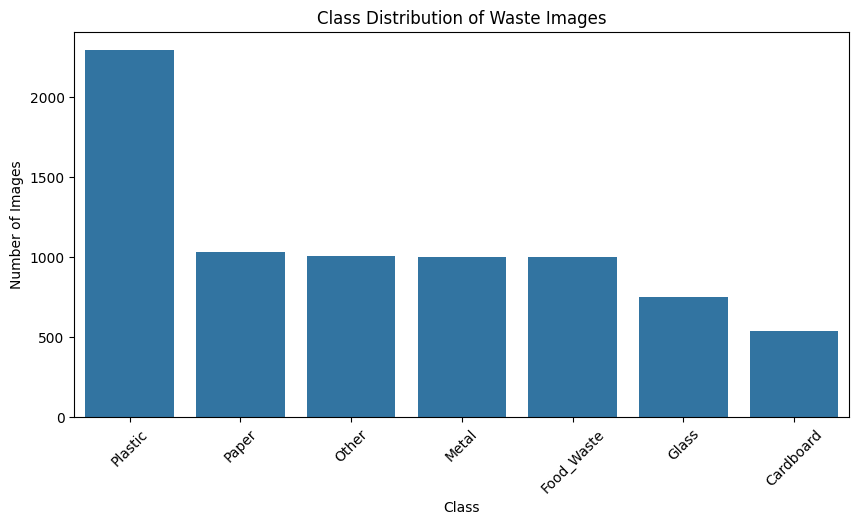

Plastic       2295
Paper         1030
Other         1010
Metal         1000
Food_Waste    1000
Glass          750
Cardboard      540
Name: count, dtype: int64


In [11]:
# Visualise Data Distribution
label_counts = pd.Series(labels).value_counts()

plt.figure(figsize=(10, 5))
sns.barplot(x=label_counts.index, y=label_counts.values)
plt.title('Class Distribution of Waste Images')
plt.xlabel('Class')
plt.ylabel('Number of Images')
plt.xticks(rotation=45)
plt.show()

print(label_counts)


#### **2.2.2** <font color=red> [3 marks] </font><br>
Visualise some sample images

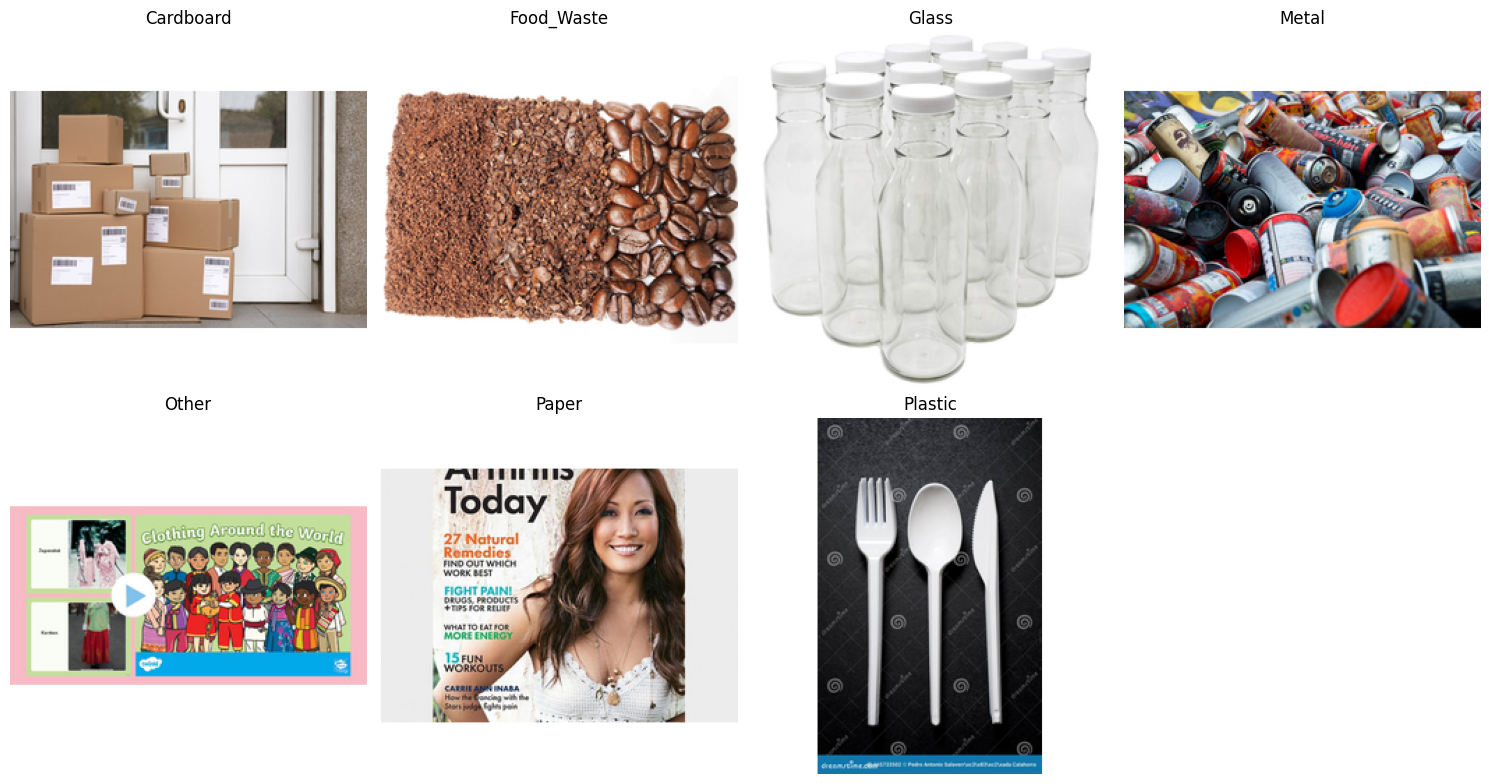

In [12]:
# Visualise Sample Images (across different labels)
unique_labels = sorted(set(labels))

plt.figure(figsize=(15, 8))
for i, label in enumerate(unique_labels):
    idx = labels.index(label)
    plt.subplot(2, 4, i + 1)
    plt.imshow(images[idx])
    plt.title(label)
    plt.axis('off')

plt.tight_layout()
plt.show()


#### **2.2.3** <font color=red> [3 marks] </font><br>
Based on the smallest and largest image dimensions, resize the images.

In [13]:
# Find the smallest and largest image dimensions from the data set
heights = [img.shape[0] for img in images]
widths  = [img.shape[1] for img in images]

print(f"Height — min: {min(heights)}, max: {max(heights)}")
print(f"Width  — min: {min(widths)}, max: {max(widths)}")


Height — min: 256, max: 256
Width  — min: 256, max: 256


In [14]:
# Resize the image dimensions
IMG_SIZE = 128

images_resized = np.array([
    np.array(Image.fromarray(img).resize((IMG_SIZE, IMG_SIZE)))
    for img in images
])

print(images_resized.shape)

(7625, 128, 128, 3)


### **2.3 Encoding the classes** <font color=red> [3 marks] </font><br>

There are seven classes present in the data.

We have extracted the images and their labels, and visualised their distribution. Now, we need to perform encoding on the labels. Encode the labels suitably.

####**2.3.1** <font color=red> [3 marks] </font><br>
Encode the target class labels.

In [15]:
# Encode the labels suitably
from sklearn.preprocessing import LabelEncoder
from tensorflow.keras.utils import to_categorical

#Step 1 convert text labels to integers
le = LabelEncoder()
labels_encoded = le.fit_transform(labels)

#Step 2 now integers to one-hot vectors
labels_onehot = to_categorical(labels_encoded)

#Check the mapings
print("Classes:", le.classes_)
print("Example:", labels[0], "->", labels_encoded[0], "->", labels_onehot[0])
print("One-hot shape:", labels_onehot.shape)


Classes: ['Cardboard' 'Food_Waste' 'Glass' 'Metal' 'Other' 'Paper' 'Plastic']
Example: Glass -> 2 -> [0. 0. 1. 0. 0. 0. 0.]
One-hot shape: (7625, 7)


### **2.4 Data Splitting** <font color=red> [5 marks] </font><br>

#### **2.4.1** <font color=red> [5 marks] </font><br>
Split the dataset into training and validation sets

In [27]:
# Assign specified parts of the dataset to train and validation sets

from sklearn.model_selection import train_test_split

#Updating to 80/10/10 split
X_temp, X_test, y_temp, y_test, enc_temp, enc_test = train_test_split(
    images_resized, labels_onehot, labels_encoded,
    test_size=0.10, stratify=labels_encoded, random_state=42)


X_train, X_val, y_train, y_val, enc_train, enc_val = train_test_split(
    X_temp, y_temp, enc_temp,
    test_size=1/9, stratify=enc_temp, random_state=42)

print("Train:", X_train.shape)
print("Val:  ", X_val.shape)
print("Test: ", X_test.shape)

Train: (6099, 128, 128, 3)
Val:   (763, 128, 128, 3)
Test:  (763, 128, 128, 3)


## **3. Model Building and Evaluation** <font color=red> [20 marks] </font><br>

### **3.1 Model building and training** <font color=red> [15 marks] </font><br>

#### **3.1.1** <font color=red> [10 marks] </font><br>
Build and compile the model. Use 3 convolutional layers. Add suitable normalisation, dropout, and fully connected layers to the model.

Test out different configurations and report the results in conclusions.

In [28]:
# Build and compile the model
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (Input, Rescaling, Conv2D, BatchNormalization,
                                      MaxPooling2D, GlobalAveragePooling2D, Dense, Dropout)
from tensorflow.keras.optimizers import Adam

model = Sequential([
    Input(shape=(128, 128, 3)),
    Rescaling(1./255),

    Conv2D(64, (3, 3), activation='relu', padding='same'),
    BatchNormalization(),
    MaxPooling2D((2, 2)),

    Conv2D(128, (3, 3), activation='relu', padding='same'),
    BatchNormalization(),
    MaxPooling2D((2, 2)),

    Conv2D(256, (3, 3), activation='relu', padding='same'),
    BatchNormalization(),
    MaxPooling2D((2, 2)),

    GlobalAveragePooling2D(),
    Dense(256, activation='relu'),
    BatchNormalization(),
    Dropout(0.3),
    Dense(7, activation='softmax')
])

model.compile(optimizer=Adam(learning_rate=1e-3),
              loss='categorical_crossentropy',
              metrics=['accuracy'])


model.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rescaling_3 (Rescaling)         │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_9 (Conv2D)               │ (None, 128, 128, 64)   │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_9           │ (None, 128, 128, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_9 (MaxPooling2D)  │ (None, 64, 64, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_10 (Conv2D)              │ (None, 64, 64, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_10          │ (None, 64, 64, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_10 (MaxPooling2D) │ (None, 32, 32, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_11 (Conv2D)              │ (None, 32, 32, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_11          │ (None, 32, 32, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_11 (MaxPooling2D) │ (None, 16, 16, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_2      │ (None, 256)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 256)            │        65,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_12          │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 7)              │         1,799 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 441,223 (1.68 MB)

 Trainable params: 439,815 (1.68 MB)

 Non-trainable params: 1,408 (5.50 KB)

#### **3.1.2** <font color=red> [5 marks] </font><br>
Train the model.

Use appropriate metrics and callbacks as needed.

In [29]:
# Training
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

from sklearn.utils.class_weight import compute_class_weight

weights = compute_class_weight('balanced', classes=np.unique(enc_train), y=enc_train)
class_weights = dict(enumerate(weights))

early_stop = EarlyStopping(monitor='val_loss', patience=8,
                           restore_best_weights=True)
reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.5,
                              patience=3, min_lr=1e-6)

history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=50,
    batch_size=32,
    callbacks=[early_stop, reduce_lr],
    class_weight=class_weights)

Epoch 1/50
191/191 ━━━━━━━━━━━━━━━━━━━━ 31s 105ms/step - accuracy: 0.2989 - loss: 1.9289 - val_accuracy: 0.1743 - val_loss: 2.4141 - learning_rate: 0.0010
Epoch 2/50
191/191 ━━━━━━━━━━━━━━━━━━━━ 8s 43ms/step - accuracy: 0.3599 - loss: 1.7271 - val_accuracy: 0.3054 - val_loss: 2.2866 - learning_rate: 0.0010
Epoch 3/50
191/191 ━━━━━━━━━━━━━━━━━━━━ 8s 43ms/step - accuracy: 0.3722 - loss: 1.6263 - val_accuracy: 0.2700 - val_loss: 2.2088 - learning_rate: 0.0010
Epoch 4/50
191/191 ━━━━━━━━━━━━━━━━━━━━ 8s 43ms/step - accuracy: 0.4220 - loss: 1.5168 - val_accuracy: 0.3591 - val_loss: 1.9652 - learning_rate: 0.0010
Epoch 5/50
191/191 ━━━━━━━━━━━━━━━━━━━━ 8s 42ms/step - accuracy: 0.4650 - loss: 1.3863 - val_accuracy: 0.2779 - val_loss: 2.6881 - learning_rate: 0.0010
Epoch 6/50
191/191 ━━━━━━━━━━━━━━━━━━━━ 8s 43ms/step - accuracy: 0.4881 - loss: 1.3285 - val_accuracy: 0.2398 - val_loss: 2.9530 - learning_rate: 0.0010
Epoch 7/50
191/191 ━━━━━━━━━━━━━━━━━━━━ 8s 42ms/step - accuracy: 0.5117 - loss: 

### **3.2 Model Testing and Evaluation** <font color=red> [5 marks] </font><br>

#### **3.2.1** <font color=red> [5 marks] </font><br>
Evaluate the model on test dataset. Derive appropriate metrics.

24/24 ━━━━━━━━━━━━━━━━━━━━ 4s 77ms/step
              precision    recall  f1-score   support

   Cardboard       0.68      0.78      0.72        54
  Food_Waste       0.76      0.71      0.73       100
       Glass       0.72      0.73      0.73        75
       Metal       0.85      0.82      0.83       100
       Other       0.57      0.67      0.62       101
       Paper       0.58      0.67      0.62       103
     Plastic       0.84      0.71      0.77       230

    accuracy                           0.72       763
   macro avg       0.71      0.73      0.72       763
weighted avg       0.74      0.72      0.73       763



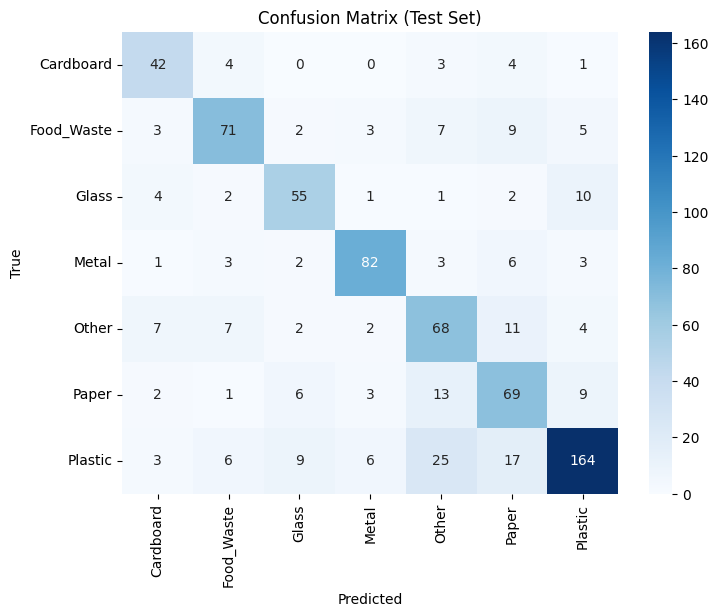

In [30]:
# Evaluate on the test set; display suitable metrics
from sklearn.metrics import classification_report, confusion_matrix



y_pred = np.argmax(model.predict(X_test), axis=1)
y_true = np.argmax(y_test, axis=1)

print(classification_report(y_true, y_pred, target_names=le.classes_))

cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=le.classes_, yticklabels=le.classes_)
plt.xlabel('Predicted'); plt.ylabel('True'); plt.title('Confusion Matrix for (Test Set)')
plt.show()

## **4. Data Augmentation** <font color=red> [optional] </font><br>

#### **4.1 Create a Data Augmentation Pipeline**

##### **4.1.1**
Define augmentation steps for the datasets.

In [37]:
# Define augmentation steps to augment images
from tensorflow.keras.layers import RandomFlip, RandomRotation, RandomZoom

data_augmentation = Sequential([
    RandomFlip('horizontal'),
    RandomRotation(0.05),
    RandomZoom(0.05),
], name='data_augmentation')

Augment and resample the images.
In case of class imbalance, you can also perform adequate undersampling on the majority class and augment those images to ensure consistency in the input datasets for both classes.

Augment the images.

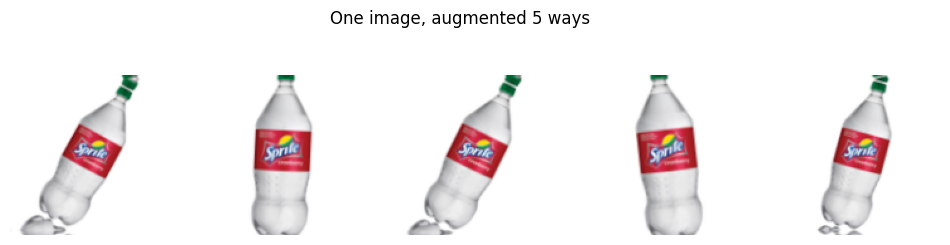

In [24]:
# Create a function to augment the images

def augment_images(image_batch):
    """Apply the augmentation pipeline to a batch of images!!"""
    return data_augmentation(image_batch, training=True)

#Now lets visualise: same image, augmented 5 different ways lets go
sample = X_train[0]
plt.figure(figsize=(12, 3))
for i in range(5):
    aug = augment_images(np.expand_dims(sample, 0))[0]
    plt.subplot(1, 5, i + 1)
    plt.imshow(aug.numpy().astype('uint8'))
    plt.axis('off')
plt.suptitle('One image, augmented 5 ways')
plt.show()



In [38]:
# Create the augmented training dataset

#Improved model + augmentation baked in, lets see how it changes the summary
model_aug = Sequential([
    Input(shape=(128, 128, 3)),
    data_augmentation,
    Rescaling(1./255),

    Conv2D(64, (3, 3), activation='relu', padding='same'),
    BatchNormalization(),
    MaxPooling2D((2, 2)),

    Conv2D(128, (3, 3), activation='relu', padding='same'),
    BatchNormalization(),
    MaxPooling2D((2, 2)),

    Conv2D(256, (3, 3), activation='relu', padding='same'),
    BatchNormalization(),
    MaxPooling2D((2, 2)),

    GlobalAveragePooling2D(),
    Dense(256, activation='relu'),
    BatchNormalization(),
    Dropout(0.3),
    Dense(7, activation='softmax')
])

model_aug.compile(optimizer=Adam(learning_rate=5e-4),
                  loss='categorical_crossentropy',
                  metrics=['accuracy'])
model_aug.summary()

Model: "sequential_8"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ data_augmentation (Sequential)  │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling_8 (Rescaling)         │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_24 (Conv2D)              │ (None, 128, 128, 64)   │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_29          │ (None, 128, 128, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_24 (MaxPooling2D) │ (None, 64, 64, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_25 (Conv2D)              │ (None, 64, 64, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_30          │ (None, 64, 64, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_25 (MaxPooling2D) │ (None, 32, 32, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_26 (Conv2D)              │ (None, 32, 32, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_31          │ (None, 32, 32, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_26 (MaxPooling2D) │ (None, 16, 16, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_7      │ (None, 256)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_16 (Dense)                │ (None, 256)            │        65,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_32          │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_8 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_17 (Dense)                │ (None, 7)              │         1,799 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 441,223 (1.68 MB)

 Trainable params: 439,815 (1.68 MB)

 Non-trainable params: 1,408 (5.50 KB)

##### **4.1.2**

Train the model on the new augmented dataset.

In [39]:
# Train the model using augmented images
early_stop = EarlyStopping(monitor='val_loss', patience=15,
                           restore_best_weights=True)
reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.5,
                              patience=6, min_lr=1e-6)

history_aug = model_aug.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=100,
    batch_size=32,
    callbacks=[early_stop, reduce_lr],
    class_weight=class_weights)

Epoch 1/100
191/191 ━━━━━━━━━━━━━━━━━━━━ 20s 87ms/step - accuracy: 0.2958 - loss: 1.9466 - val_accuracy: 0.0996 - val_loss: 2.4415 - learning_rate: 5.0000e-04
Epoch 2/100
191/191 ━━━━━━━━━━━━━━━━━━━━ 16s 81ms/step - accuracy: 0.3420 - loss: 1.7508 - val_accuracy: 0.2516 - val_loss: 1.9747 - learning_rate: 5.0000e-04
Epoch 3/100
191/191 ━━━━━━━━━━━━━━━━━━━━ 15s 78ms/step - accuracy: 0.3886 - loss: 1.6447 - val_accuracy: 0.3421 - val_loss: 1.8780 - learning_rate: 5.0000e-04
Epoch 4/100
191/191 ━━━━━━━━━━━━━━━━━━━━ 15s 78ms/step - accuracy: 0.4027 - loss: 1.5678 - val_accuracy: 0.2844 - val_loss: 2.1207 - learning_rate: 5.0000e-04
Epoch 5/100
191/191 ━━━━━━━━━━━━━━━━━━━━ 15s 79ms/step - accuracy: 0.4222 - loss: 1.5228 - val_accuracy: 0.3093 - val_loss: 1.9228 - learning_rate: 5.0000e-04
Epoch 6/100
191/191 ━━━━━━━━━━━━━━━━━━━━ 15s 81ms/step - accuracy: 0.4358 - loss: 1.4854 - val_accuracy: 0.2241 - val_loss: 2.7621 - learning_rate: 5.0000e-04
Epoch 7/100
191/191 ━━━━━━━━━━━━━━━━━━━━ 15s 7

In [40]:
# Evaluate the augmented model on the test set (for fair comparison)
y_pred_aug = np.argmax(model_aug.predict(X_test), axis=1)
y_true = np.argmax(y_test, axis=1)

print("=== Fixed augmented model  Test set ===")
print(classification_report(y_true, y_pred_aug, target_names=le.classes_, zero_division=0))

24/24 ━━━━━━━━━━━━━━━━━━━━ 1s 51ms/step
=== Fixed augmented model — Test set ===
              precision    recall  f1-score   support

   Cardboard       0.76      0.72      0.74        54
  Food_Waste       0.79      0.68      0.73       100
       Glass       0.75      0.75      0.75        75
       Metal       0.74      0.81      0.78       100
       Other       0.67      0.57      0.62       101
       Paper       0.44      0.78      0.56       103
     Plastic       0.86      0.65      0.74       230

    accuracy                           0.70       763
   macro avg       0.72      0.71      0.70       763
weighted avg       0.74      0.70      0.70       763



## **5. Conclusions** <font color = red> [5 marks]</font>

#### **5.1 Conclude with outcomes and insights gained** <font color =red> [5 marks] </font>

* Report your findings about the data
* Report model training results

## Conclusions

### First & foremost let's get into the findings about the data
- The dataset contains **7,625 images** across **7 classes** (Cardboard, Food_Waste,
  Glass, Metal, Other, Paper, Plastic).
- All images were **uniformly 256×256** which was confirmed by measuring dimensions, not by
  visual inspection (the sample grid was misleading because matplotlib stretches images
  to fill each cell, initially i was sure that the images were not of the same dim but data proved me wrong!). Images were resized to **128×128** to reduce compute while
  retaining detail.
- The data is **strongly imbalanced**: Plastic dominates with 2,295 images while
  Cardboard has only 540
- The **"Other"** class has  visually inconsistent
  images (including non-object pictures like ilustrations), making it the hardest
  class to classify and annoying tbh.

### Model development and results
- Base architecture: 3 convolutional blocks (Conv -> BatchNorm -> MaxPool) +
  GlobalAveragePooling + Dense + Dropout + 7-way softmax.
- **First attempt collapsed** to the majority class unfortunately accuracy frozen at exactly 30.1%
  (Plastic's share), i.e. it predicted only Plastic. Bec i didnt take into accounct the immbalence.
- **Fixes that made it learn:** class weights (imbalance), GlobalAveragePooling
  (removed a 4.2M-param bottleneck), and a lower learning rate 53% validation.
- **Tuning for higher accuracy:** wider filters (64/128/256), reduced dropout (0.3),
  and an Adam + ReduceLROnPlateau learning-rate schedule with longer training which took time but the results were worth it
  **72% test accuracy, macro-F1 0.72** on a held-out 80/10/10 split.
- **Per-class:** Metal (F1 0.83) and Plastic (0.77) strongest; **Other (0.62)** weakest,
  matching the data analysis. Balanced macro vs weghted F1 confirms the imbalance
  was successfully handled.

### Data augmentation experiment
- Initial augmentation appeared to fail (18% test accuracy, collapsing to a few classes).
  Diagnosis: the model **did not converge**  highly unstable validation (loss spikes)
  caused by overly aggressive augmentation and premature learning-rate decay. Which was a good learning curve as it help me understand how to improve it.
- **Fixed** with gentler transforms, more patient callbacks, and longer training which took 61 Epochs but
  a **stable 70% test accuracy** with a smaller train/val gap (less overfitting) was a major win compare to its initial 18%.

### Key insights
- **Class imbalance was the central challenge** correcting it (class weights) was the
  single most impactful change, far more than augmentation. Which should have been done at the first go only but hey we learn with each iteration.
- Augmentation, once properly converged, produced a **more robust but marginally less
  accurate** model (70% vs 72%). The non-augmented tuned model was selected as final.
- Future gains would most likely come from **transfer learning** (e.g. a pre-trained
  MobileNetV2 / EfficientNet backbone), which typicaly reaches 80%+ on datasets this size. Can't wait to try these out to see how much i can improve the accuracy, for now this is it.